In [1]:
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from sqlalchemy import create_engine

username = 'root'
password = '7999590423'
host = 'localhost'
port = '3306'
database = 'superstore_db'

engine = create_engine(
    f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}'
)

In [3]:
with engine.connect() as conn:
    print('Connected to MYSQL successfully')

Connected to MYSQL successfully


In [4]:
## Data Reading :

query = """
SELECT 
   o.order_id,
    o.customer_id,
    o.product_id,
    o.order_date,
    o.ship_date,
    o.ship_mode,
    o.country,
    o.state,
    o.city,
    o.region,
    o.postal_code,
    o.sales,
    o.quantity,
    o.discount,
    o.profit,
    o.shipping_cost,

    p.product_name,
    p.category,
    p.sub_category,

    c.customer_name,
    c.segment,

    COALESCE(r.Returned,'No') AS returned,
    r.market

FROM orders o
JOIN products p
ON o.product_id = p.product_id

JOIN customers c
ON o.customer_id = c.customer_id

LEFT JOIN returns r
ON o.order_id = r.`Order ID`;
"""
df = pd.read_sql(query, engine)
df

,order_id,customer_id,product_id,order_date,ship_date,ship_mode,country,state,city,region,...,discount,profit,shipping_cost,product_name,category,sub_category,customer_name,segment,returned,market
0,CG-2014-7660,PH-8790,FUR-ADV-10000002,2014-05-08,2014-05-13,Standard Class,Democratic Republic of the Congo,Kinshasa,Kinshasa,Africa,...,0.0,40.26,6.11,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Patricia Hirasaki,Home Office,No,None
1,IZ-2014-4660,TB-11190,FUR-ADV-10000002,2014-09-08,2014-09-15,Standard Class,Iraq,Baghdad,Baghdad,EMEA,...,0.0,20.13,4.03,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Thomas Brumley,Home Office,No,None
2,RW-2012-8200,SG-10890,FUR-ADV-10000108,2012-02-20,2012-02-24,Standard Class,Rwanda,Kigali,Kigali,Africa,...,0.0,1.92,10.80,"Advantus Clock, Erganomic",Furniture,Furnishings,Susan Gilcrest,Corporate,No,None
3,LI-2011-9980,PM-9135,FUR-ADV-10000108,2011-04-13,2011-04-15,Second Class,Liberia,Montserrado,Monrovia,Africa,...,0.0,0.96,9.27,"Advantus Clock, Erganomic",Furniture,Furnishings,Peter McVee,Home Office,No,None
4,MO-2012-8110,AR-540,FUR-ADV-10000108,2012-05-10,2012-05-17,Standard Class,Morocco,Grand Casablanca,Casablanca,Africa,...,0.0,0.48,2.83,"Advantus Clock, Erganomic",Furniture,Furnishings,Andy Reiter,Consumer,No,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51290,MZ-2013-3540,EH-4005,TEC-STA-10004542,2013-04-19,2013-04-23,Standard Class,Mozambique,Sofala,Beira,Africa,...,0.0,12.00,4.68,"StarTech Calculator, Durable",Technology,Machines,Erica Hernandez,Home Office,No,None
51291,TU-2014-8160,SC-10260,TEC-STA-10004542,2014-07-07,2014-07-13,Standard Class,Turkey,Istanbul,Istanbul,EMEA,...,0.6,-18.05,1.62,"StarTech Calculator, Durable",Technology,Machines,Scott Cohen,Corporate,No,None
51292,TU-2011-790,CC-2145,TEC-STA-10004834,2011-11-03,2011-11-08,Standard Class,Turkey,Adana,Adana,EMEA,...,0.6,-107.83,13.61,"StarTech Receipt Printer, Red",Technology,Machines,Charles Crestani,Consumer,No,None
51293,NI-2013-7410,CD-1920,TEC-STA-10004834,2013-08-28,2013-09-03,Standard Class,Nigeria,Kano,Kano,Africa,...,0.7,-37.73,5.77,"StarTech Receipt Printer, Red",Technology,Machines,Carlos Daly,Consumer,No,None


In [15]:
 # Changing the data type of shipping_date and order_date column 

df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [16]:
# # dropping the market column

df.drop(columns = ['market'], inplace = True)

# Sales & Profit Analysis :

### Observing overall Business Perfomance :

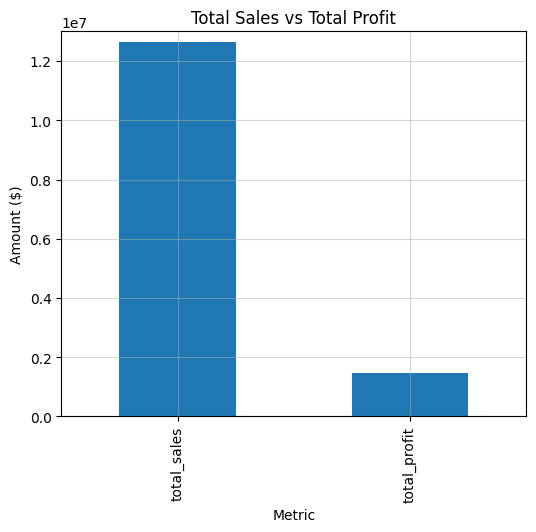

In [157]:
# Total sales vs Total Profit

query = """
SELECT 
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit
FROM orders;
"""

total_sales_and_profit = pd.read_sql(query, engine)

total_sales_and_profit.T.plot(kind='bar', legend=False, figsize=(6,5))

plt.title('Total Sales vs Total Profit')
plt.xlabel('Metric')
plt.ylabel('Amount ($)')
plt.grid(alpha = 0.5)
plt.ylim(0, 13000000)

plt.show()

### Average Order Value: **(KPI)**

In [158]:
query = """
SELECT 
    SUM(sales) / COUNT(DISTINCT order_id) AS avg_order_value
FROM orders;
"""
avg_order_value = pd.read_sql(query, engine)

In [109]:
avg_order_value

,avg_order_value
0,504.993299


In [35]:
total_sales_and_profit

,total_sales,total_profit
0,12642507.25,1467456.55


### Year wise Sales & Profit

In [ ]:
query = """
SELECT 
    YEAR(order_date) AS order_year,
    ROUND(SUM(sales), 2)AS yearly_sales,
    ROUND(SUM(profit),2)AS yearly_profit
FROM orders
GROUP BY YEAR(order_date)
ORDER BY order_year;
"""

year_wise_sales_and_profit = pd.read_sql(query, engine)

In [36]:
year_wise_sales_and_profit

,order_year,yearly_sales,yearly_profit
0,2011,2259451.64,248940.41
1,2012,2677439.91,307415.30
2,2013,3405748.03,406934.84
3,2014,4299867.67,504166.00


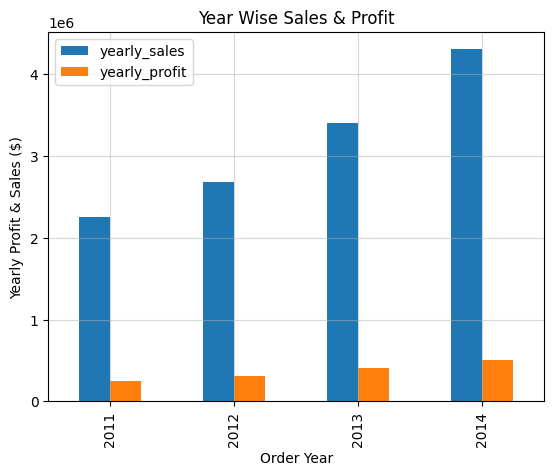

In [159]:
year_wise_sales_and_profit.plot(
    x='order_year',
    y=['yearly_sales','yearly_profit'],
    kind='bar',
)

plt.title('Year Wise Sales & Profit')
plt.xlabel('Order Year')
plt.ylabel('Yearly Profit & Sales ($)')
plt.grid(alpha = 0.5)


### Monthly sales trend 

In [ ]:
query = """
SELECT
    YEAR(order_date)  AS order_year,
    MONTH(order_date) AS order_month,
    ROUND(SUM(sales), 2) AS monthly_sales
FROM orders
GROUP BY
    YEAR(order_date),
    MONTH(order_date)
ORDER BY
    order_year,
    order_month;
"""
monthly_sales_trend = pd.read_sql(query, engine)

In [41]:
monthly_sales_trend.head(10)

,order_year,order_month,monthly_sales
0,2011,1,98898.53
1,2011,2,91152.23
2,2011,3,145729.51
3,2011,4,116915.78
4,2011,5,146747.86
5,2011,6,215207.41
6,2011,7,115510.44
7,2011,8,207581.50
8,2011,9,290214.54
9,2011,10,199071.29


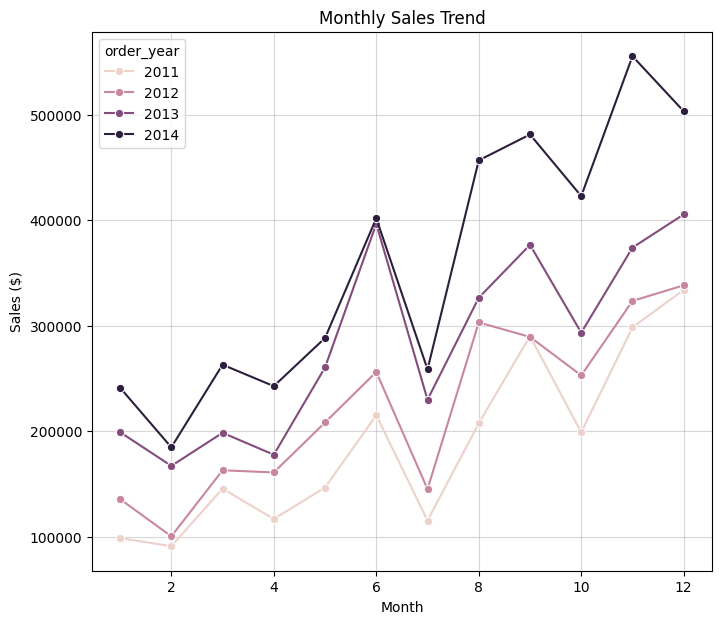

In [47]:
plt.figure(figsize=(8,7))

sns.lineplot(
    x='order_month',
    y='monthly_sales',
    hue='order_year',
    data=monthly_sales_trend,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.grid(alpha = 0.5)
plt.xlabel('Month')
plt.ylabel('Sales ($)')

plt.show()

### Sales and profit by category

In [83]:
query = """
SELECT
    p.category,
    ROUND(SUM(o.sales), 2) AS category_sales,
    ROUND(SUM(o.profit), 2) AS category_profit
FROM orders o 
JOIN products p  
ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY category_sales DESC
LIMIT 10;
"""

sales_and_profit_by_category = pd.read_sql(query, engine)

In [84]:
sales_and_profit_by_category

,category,category_sales,category_profit
0,Technology,4744558.76,663779.25
1,Furniture,4110875.32,285204.56
2,Office Supplies,3787073.17,518472.74


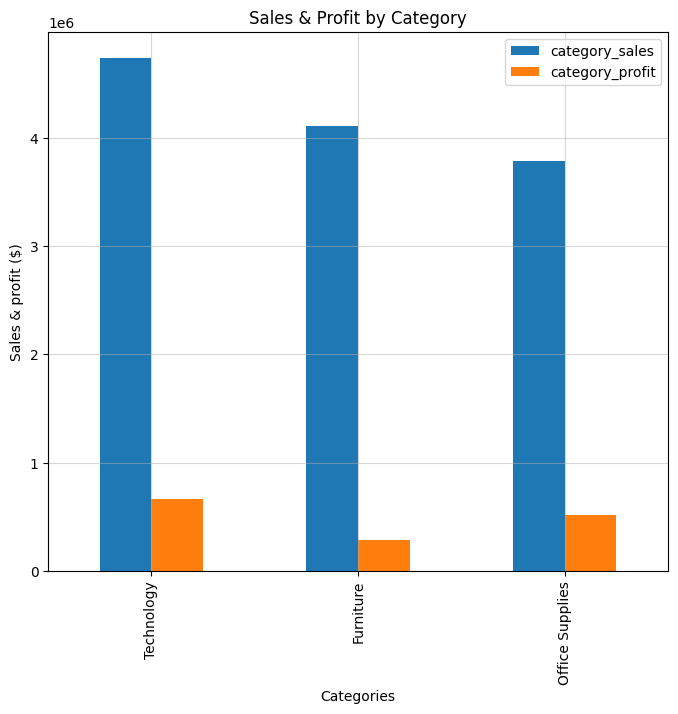

In [85]:
sales_and_profit_by_category.plot(x = 'category',
                                  y = ['category_sales','category_profit'],
                                  kind = 'bar',
                                  figsize =(8,7)
                                 )
plt.title('Sales & Profit by Category')
plt.xlabel('Categories')
plt.ylabel('Sales & profit ($)')
plt.grid(alpha = 0.5)

plt.show()

### Sub-category with negative profit


In [156]:
query = """
SELECT 
    p.sub_category,
    ROUND(SUM(o.sales), 2) AS total_sales,
    ROUND(SUM(o.profit), 2) AS total_profit
FROM orders o  
JOIN products p 
ON o.product_id = p.product_id 
GROUP BY p.sub_category
HAVING total_profit < 0
ORDER BY total_profit;
"""
sub_category_with_negative_profit = pd.read_sql(query, engine)

sub_category_with_negative_profit

,sub_category,total_sales,total_profit
0,Tables,757042.17,-64083.55


### Top performing products in sales :

In [54]:
query = """
SELECT 
    p.product_name,
    ROUND(SUM(o.sales), 2) AS total_sales
FROM orders o 
JOIN products p 
ON o.product_id = p.product_id
GROUP BY p.product_name 
ORDER BY total_sales DESC 
LIMIT 10;
"""
best_performing_products = pd.read_sql(query, engine)

In [55]:
best_performing_products

,product_name,total_sales
0,"Apple Smart Phone, Full Size",86935.79
1,"Cisco Smart Phone, Full Size",76441.53
2,"Motorola Smart Phone, Full Size",73156.33
3,"Nokia Smart Phone, Full Size",71904.56
4,Canon imageCLASS 2200 Advanced Copier,61599.83
5,"Hon Executive Leather Armchair, Adjustable",58193.52
6,"Harbour Creations Executive Leather Armchair, ...",50121.52
7,"Samsung Smart Phone, Cordless",48653.46
8,"Nokia Smart Phone, with Caller ID",47877.80
9,"Office Star Executive Leather Armchair, Adjust...",45837.17


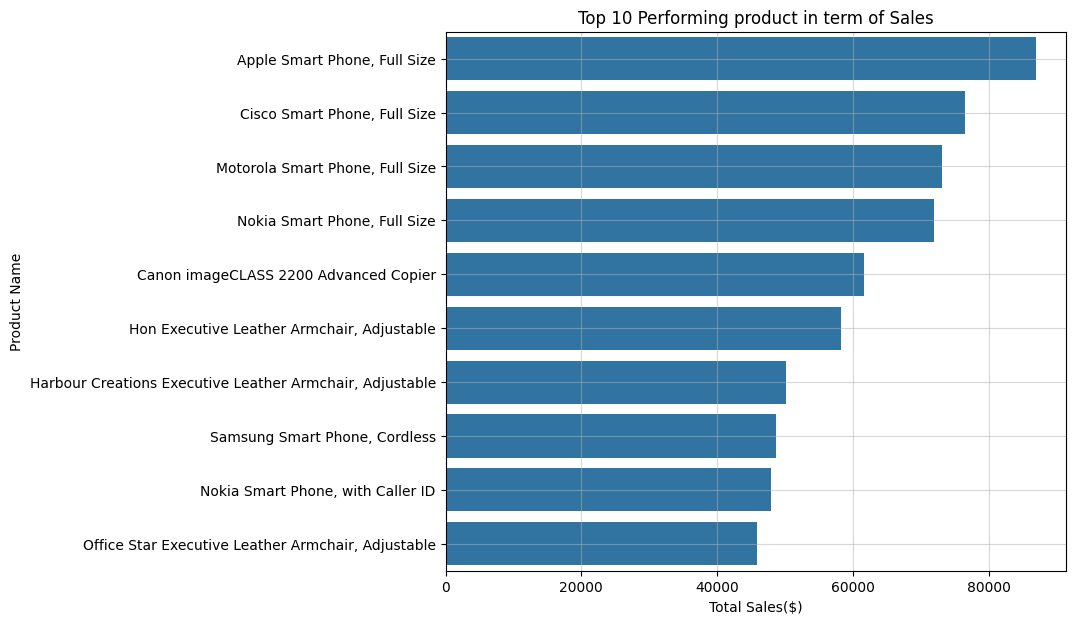

In [58]:
plt.figure(figsize = (8,7))

sns.barplot(x = 'total_sales', 
            y = 'product_name',
            data = best_performing_products
           )
plt.title('Top 10 Performing product in term of Sales')

plt.xlabel('Total Sales($)')
plt.ylabel('Product Name')
plt.grid(alpha = 0.5)

plt.show()



### Top 10 products by Profit

In [60]:
query = """
SELECT 
    p.product_name,
    ROUND(SUM(o.profit), 2) AS total_profit
FROM orders o  
JOIN products p  
ON o.product_id = p.product_id
GROUP BY p.product_name
ORDER BY total_profit DESC 
LIMIT 10;
"""
top_products_by_profit = pd.read_sql(query, engine)

In [61]:
top_products_by_profit

,product_name,total_profit
0,Canon imageCLASS 2200 Advanced Copier,25199.94
1,"Cisco Smart Phone, Full Size",17238.52
2,"Motorola Smart Phone, Full Size",17027.14
3,"Hoover Stove, Red",11728.69
4,"Sauder Classic Bookcase, Traditional",10672.06
5,"Harbour Creations Executive Leather Armchair, ...",10427.33
6,"Cisco Smart Phone, with Caller ID",10192.32
7,"Nokia Smart Phone, Full Size",9938.16
8,"Nokia Smart Phone, with Caller ID",9465.34
9,"Belkin Router, USB",9384.74


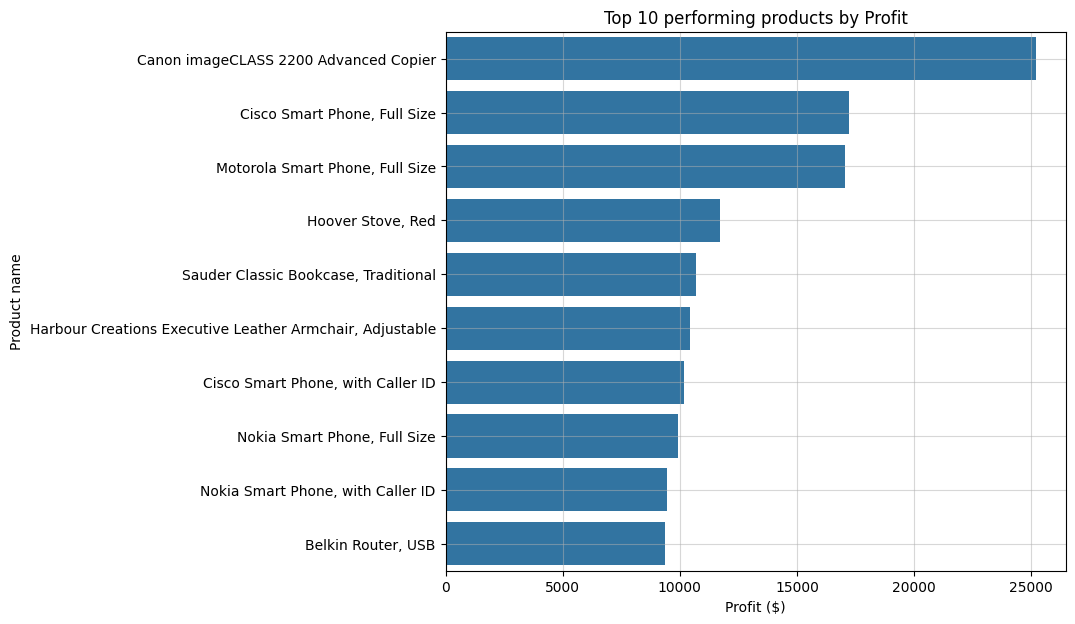

In [62]:
plt.figure(figsize = (8,7))

sns.barplot(x = 'total_profit',
            y = 'product_name',
            data = top_products_by_profit)

plt.title('Top 10 performing products by Profit')

plt.xlabel('Profit ($)')
plt.ylabel('Product name')
plt.grid(alpha = 0.5)

plt.show()

### Products with high sales but low profit or negative profit

In [66]:
query = """
SELECT 
    p.product_name,
    ROUND(SUM(o.sales), 2) AS total_sales,
    ROUND(SUM(o.profit), 2) AS total_profit
FROM orders o  
JOIN products p 
ON o.product_id = p.product_id
GROUP BY p.product_name
HAVING total_sales > 10000
    AND total_profit < 0
ORDER BY total_sales DESC
LIMIT 10;
"""
products_with_highsales_lowprofit = pd.read_sql(query, engine)


In [67]:
products_with_highsales_lowprofit

,product_name,total_sales,total_profit
0,"Samsung Smart Phone, Cordless",48653.46,-198.09
1,"Motorola Smart Phone, Cordless",38931.04,-4447.04
2,"Hoover Stove, White",32842.61,-2180.63
3,"Rogers Lockers, Blue",28214.58,-2893.50
4,"SAFCO Executive Leather Armchair, Red",25640.12,-1833.18
5,"Smead File Cart, Single Width",25397.16,-237.69
6,"Apple Signal Booster, Cordless",24604.19,-423.55
7,"Bevis Conference Table, Fully Assembled",24431.68,-4377.49
8,Cisco TelePresence System EX90 Videoconferenci...,22638.48,-1811.08
9,"Ikea Library with Doors, Pine",22536.06,-277.96


<Figure size 800x700 with 0 Axes>

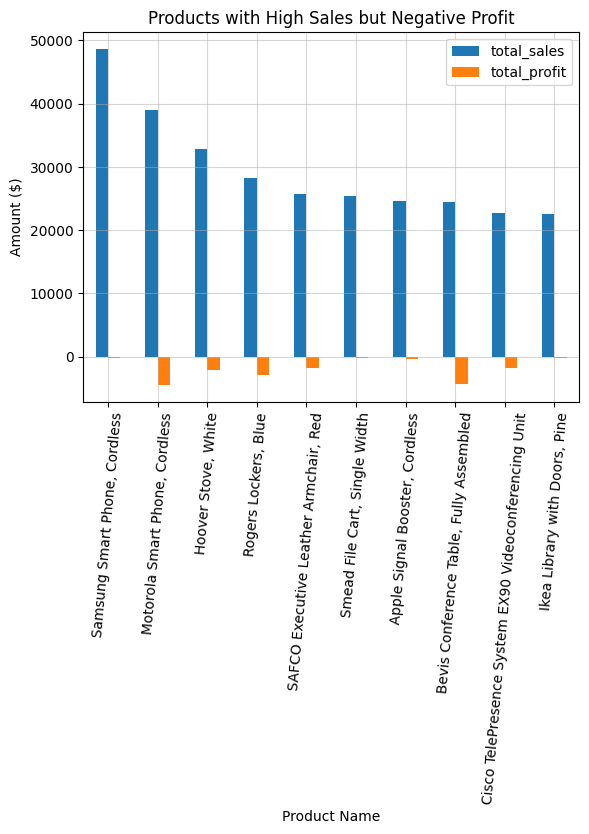

In [73]:
plt.figure(figsize=(8,7))

products_with_highsales_lowprofit.plot(
    x='product_name',
    y=['total_sales','total_profit'],
    kind='bar',
)

plt.title('Products with High Sales but Negative Profit')
plt.xlabel('Product Name')
plt.ylabel('Amount ($)')
plt.xticks(rotation=85)
plt.grid(alpha = 0.5)

plt.show()

### Profit margin by category : **(KPI)**

In [87]:
query = """
SELECT 
    p.category,
    ROUND(SUM(o.profit) / SUM(o.sales) * 100, 2) AS profit_margin_pct
FROM orders o 
JOIN products p 
ON o.product_id = p.product_id
GROUP BY p.category;
"""
profit_margin_by_category = pd.read_sql(query, engine)


In [88]:
profit_margin_by_category.head()

,category,profit_margin_pct
0,Furniture,6.94
1,Office Supplies,13.69
2,Technology,13.99


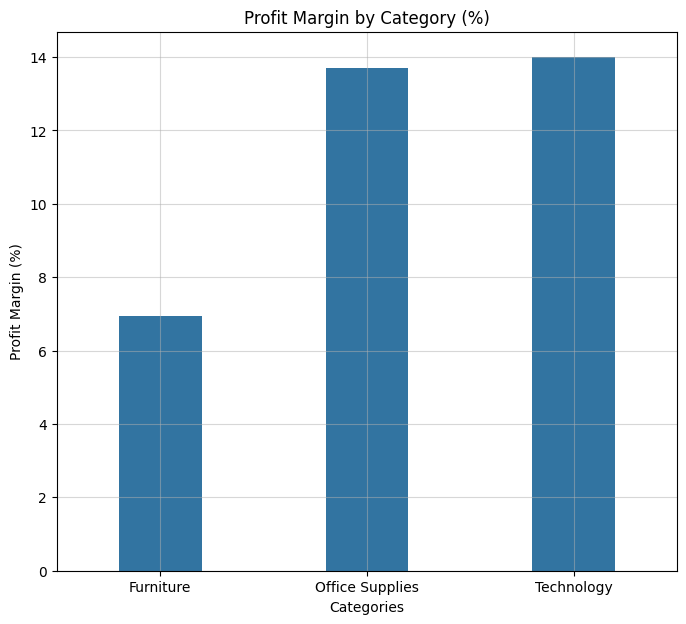

In [105]:
plt.figure(figsize=(8,7))

sns.barplot(x = 'category',
            y = 'profit_margin_pct',
            data = profit_margin_by_category,
            width = 0.4
           )
plt.title('Profit Margin by Category (%)')
plt.xlabel('Categories')
plt.ylabel('Profit Margin (%)')
plt.grid(alpha = 0.5)

plt.show()

### Year On Year (YoY) Sales Growth :

In [137]:
query = """
SELECT 
    YEAR(order_date) AS order_year,
    SUM(sales) AS total_sales
FROM orders
GROUP BY YEAR(order_date)
ORDER BY order_year;
"""

yearly_sales = pd.read_sql(query, engine)
yearly_sales

,order_year,total_sales
0,2011,2259451.64
1,2012,2677439.91
2,2013,3405748.03
3,2014,4299867.67


In [139]:
## Calculating YoY growth :

yearly_sales['yoy_sales_growth'] = (
    yearly_sales['total_sales'].pct_change() * 100
)

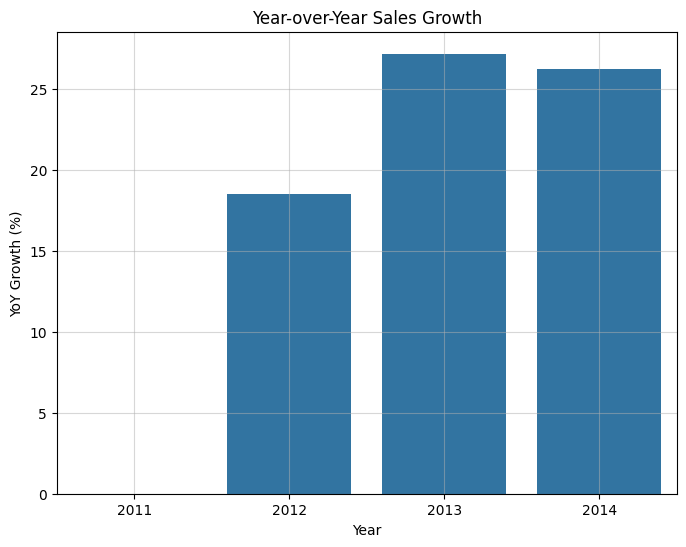

In [140]:
plt.figure(figsize=(8,6))

sns.barplot(x='order_year',
             y='yoy_sales_growth', 
             data=yearly_sales
            )

plt.title("Year-over-Year Sales Growth")
plt.xlabel("Year")
plt.ylabel("YoY Growth (%)")
plt.grid(alpha = 0.5)

plt.show()

### Year-on-Year(YoY) Profit Growth:

In [130]:
query = """
SELECT 
    YEAR(order_date) AS order_year,
    SUM(profit) AS total_profit
FROM orders
GROUP BY YEAR(order_date)
ORDER BY order_year;
"""
profit_by_year = pd.read_sql(query, engine)
profit_by_year

,order_year,total_profit
0,2011,248940.41
1,2012,307415.30
2,2013,406934.84
3,2014,504166.00


In [134]:
# Calculate YoY profit 

profit_by_year['yoy_profit_growth'] = (
    profit_by_year['total_profit'].pct_change() * 100
)

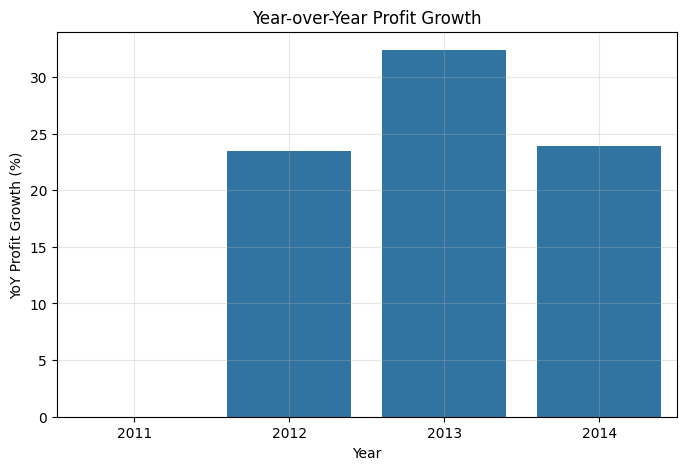

In [132]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='order_year',
    y='yoy_profit_growth',
    data=profit_by_year,
)

plt.title('Year-over-Year Profit Growth')
plt.xlabel('Year')
plt.ylabel('YoY Profit Growth (%)')


plt.grid(alpha=0.3)

plt.show()

### Month Over Month(MoM) Sales Analysis :

In [143]:
query = """
SELECT 
	YEAR(order_date) AS order_year,
    MONTH(order_date) AS order_month,
    SUM(SALES) AS total_sales
FROM orders 
GROUP BY order_year, order_month
ORDER BY order_year, order_month;
"""
sales_per_month = pd.read_sql(query , engine)
sales_per_month.head(2)


,order_year,order_month,total_sales
0,2011,1,98898.53
1,2011,2,91152.23


In [144]:
sales_per_month['mom_sales_growth'] = (
    sales_per_month['total_sales'].pct_change() * 100
)

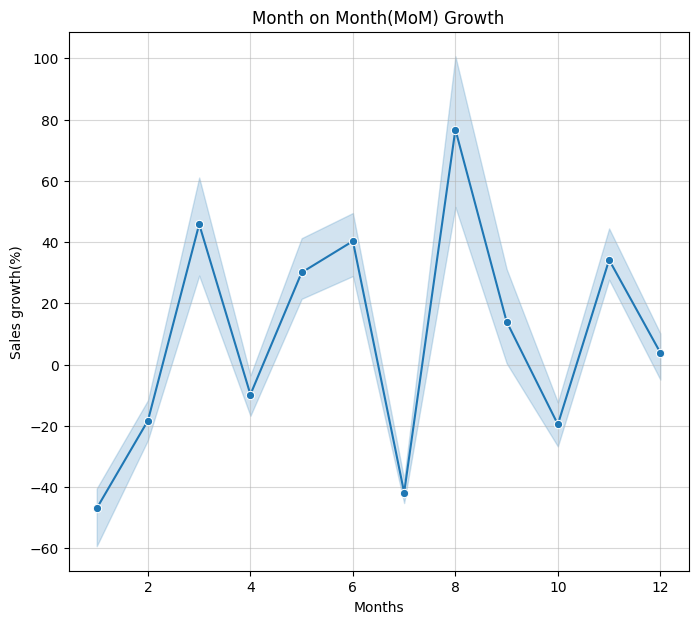

In [152]:
plt.figure(figsize = (8,7))

sns.lineplot(x = 'order_month',
            y = 'mom_sales_growth',
            data = sales_per_month,
            marker = 'o'
           )
plt.title('Month on Month(MoM) Growth')
plt.xlabel('Months')
plt.ylabel('Sales growth(%)')
plt.grid(alpha = 0.5)

plt.show()

# Summary of Sales and Profit Analysis :

## In-Depth Summary

## Key Insights: Sales & Profit Analysis

### Overall Business Performance

* The business generates **very strong sales compared to profit**, indicating that while revenue is high, profit margins are relatively smaller.
* This suggests that **cost factors such as discounts, shipping, or product costs may significantly impact profitability**.

### Sales and Profit Growth Over Time

* Both **sales and profit show consistent year-over-year growth from 2011 to 2014**, indicating strong overall business expansion.
* Profit growth appears slightly faster than sales growth in certain years, suggesting **improving profitability efficiency over time**.

### Monthly Sales Trends & Seasonality

* Sales follow a **clear seasonal pattern**, with stronger performance in the **second half of the year**.
* **November and December show the highest sales levels**, indicating strong demand during the holiday season.
* Mid-year months such as **June also show notable spikes**, while some early months show comparatively lower sales.

### Month-on-Month Sales Volatility

* Monthly growth fluctuates significantly, showing **both strong positive and negative changes between months**.
* The largest surge occurs around **late summer (around month 8)**, while some months show noticeable declines.
* This suggests **short-term demand fluctuations and possible seasonal purchasing patterns**.

### Category Performance

* **Technology generates the highest sales and profit**, making it the most valuable product category.
* **Office Supplies maintain a strong profit margin**, indicating stable profitability.
* **Furniture has the lowest profit margin**, suggesting potential pricing or discount issues affecting profitability.

### Top Performing Products

* Several **smartphone products dominate the top sales rankings**, highlighting strong demand in the technology segment.
* The **Canon imageCLASS 2200 Advanced Copier stands out as the most profitable product**, significantly outperforming others in terms of profit contribution.

### High Sales but Negative Profit Products

* Some products generate **substantial sales but result in negative profit**, indicating that they may be heavily discounted or associated with high operational costs.
* These products represent **potential financial risk and should be reviewed for pricing, discount strategies, or cost optimization**.

### Profitability Insights

* Profit margin analysis shows **Technology and Office Supplies delivering healthier margins**, while **Furniture lags behind**.
* Improving pricing strategy, reducing excessive discounts, or optimizing costs in underperforming categories could significantly enhance overall profitability.

### Overall Business Insight

* The company is experiencing **steady revenue growth and strong product demand**, particularly in technology products.
* However, **profitability is uneven across categories and products**, and certain high-volume products are negatively impacting margins.
* Addressing **discount policies, cost structures, and product pricing** could further improve overall profit performance.

---


## Short quick summary :

## Key Insights

* The business shows **steady growth in both sales and profit from 2011 to 2014**, indicating consistent expansion.

* Sales display **clear seasonal patterns**, with peaks towards the **end of the year, especially in November and December**.

* **Technology is the most profitable category**, while **Furniture has the lowest profit margin**, suggesting possible pricing or cost issues.

* Several **technology products dominate the top sales and profit rankings**, highlighting strong demand in this category.

* Some products generate **high sales but negative profit**, indicating that heavy discounts or high operational costs may be affecting profitability.

* Monthly sales growth fluctuates significantly, suggesting **periods of strong demand followed by temporary slowdowns**.
